<a href="https://colab.research.google.com/github/Godenzo0n/ml-train/blob/develop/House_price_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

# 1. EDA

In [ ]:
train_data.shape, test_data.shape

((1460, 81), (1459, 80))

## 1.1 Target distribution
https://habr.com/ru/companies/otus/articles/671322/

In [ ]:
print(f"mean {train_data.SalePrice.mean()}")
print(f"median {train_data.SalePrice.median()}")
print(f"mode {train_data.SalePrice.mode()[0]}")
print()
print(train_data.SalePrice.describe())

mean 180921.19589041095
median 163000.0
mode 140000

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


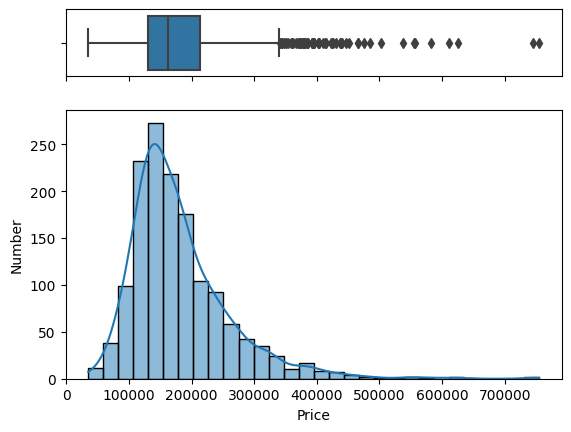

In [ ]:
fig, (ax_box, ax_hist) = plt.subplots(2,
                                    sharex = True,
                                    gridspec_kw = {'height_ratios': (.20, .80)})


sns.boxplot(x = train_data['SalePrice'], ax = ax_box)
sns.histplot(x = train_data['SalePrice'], ax = ax_hist, bins = 30, kde = True)



ax_box.set(xlabel = '')
ax_hist.set(xlabel = 'Price')
ax_hist.set(ylabel = 'Number')


plt.show()


![image.png](attachment:b611f2ef-1dc3-4a85-bfca-8d3fdb0d6c54.png)

In [ ]:
print("Skewness: %f" % train_data['SalePrice'].skew())
print("Kurtosis: %f" % train_data['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


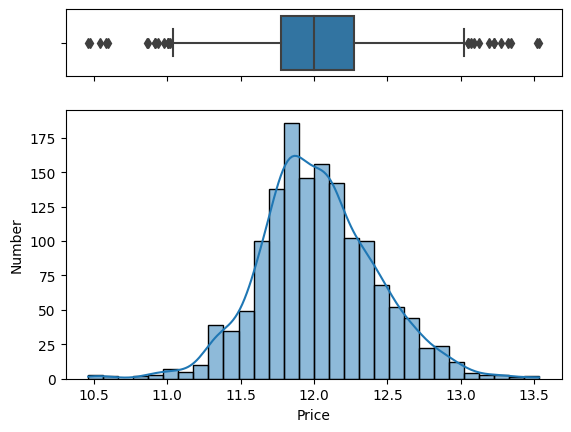

In [ ]:
fig, (ax_box, ax_hist) = plt.subplots(2,
                                    sharex = True,
                                    gridspec_kw = {'height_ratios': (.20, .80)})


sns.boxplot(x = np.log1p(train_data['SalePrice']), ax = ax_box)
sns.histplot(x = np.log1p(train_data['SalePrice']), ax = ax_hist, bins = 30, kde = True)



ax_box.set(xlabel = '')
ax_hist.set(xlabel = 'Price')
ax_hist.set(ylabel = 'Number')


plt.show()



In [ ]:
print("Skewness: %f" % np.log1p(train_data['SalePrice']).skew())
print("Kurtosis: %f" % np.log1p(train_data['SalePrice']).kurt())

Skewness: 0.121347
Kurtosis: 0.809519


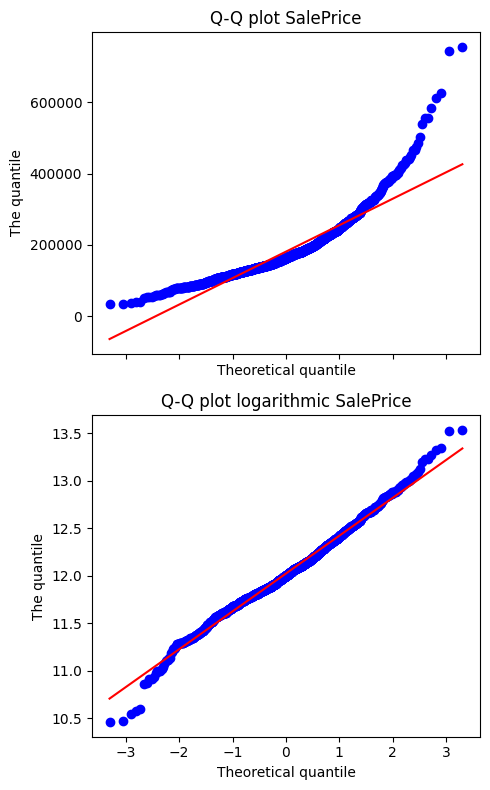

In [ ]:
fig, (ax_qq, ax_qq_log) = plt.subplots(2,
                                       sharex=True,
                                       figsize = (5,8)
                                       )


stats.probplot(train_data['SalePrice'], dist="norm", plot=ax_qq)
ax_qq.set_title('Q-Q plot SalePrice')
ax_qq.set_ylabel('The quantile')
ax_qq.set_xlabel('Theoretical quantile')

stats.probplot(np.log1p(train_data['SalePrice']), dist="norm", plot=ax_qq_log)
ax_qq_log.set_title('Q-Q plot logarithmic SalePrice')
ax_qq_log.set_ylabel('The quantile')
ax_qq_log.set_xlabel('Theoretical quantile')

plt.tight_layout()

plt.show()


https://habr.com/ru/articles/578754/

In [ ]:
#train_data['SalePrice']= np.log1p(train_data['SalePrice'])

## 1.2 Missing values
- finding missing values
- filling in the gaps

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [ ]:
train_na = (train_data.isnull().sum() / len(train_data)) * 100
train_na = train_na.drop(train_na[train_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing ratio' : train_na})
missing_data.head(30)

,Missing ratio
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


In [ ]:

test_na = (test_data.isnull().sum() / len(test_data)) * 100
test_na = test_na.drop(test_na[test_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing ratio' : test_na})
missing_data.head(30)

,Missing ratio
PoolQC,99.794380
MiscFeature,96.504455
Alley,92.666210
Fence,80.123372
MasVnrType,61.274846
FireplaceQu,50.034270
LotFrontage,15.558602
GarageCond,5.346127
GarageYrBlt,5.346127
GarageQual,5.346127


### 1.2.1 Filling numerical data
- median

In [ ]:
train_data.fillna(train_data.median(numeric_only=True), inplace=True)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

### 1.2.2 Filling categorial data
- mode

In [ ]:
train_data.fillna(train_data.mode().iloc[0], inplace=True)
test_data.fillna(test_data.mode().iloc[0], inplace=True)

In [ ]:
print('Miss train data:', train_data.isnull().sum().sum())
print('Miss test data:', test_data.isnull().sum().sum())

Miss train data: 0
Miss test data: 0


## 1.3 Numerical data

In [ ]:
train_num = train_data.select_dtypes(include = ['int64','float64'])
train_num = train_num.drop(['Id'], axis = 1)
test_num = test_data.select_dtypes(include = ['int64','float64'])
test_Id = test_data.Id
test_num = test_num.drop(['Id'], axis = 1)

### 1.3.1 Train data

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

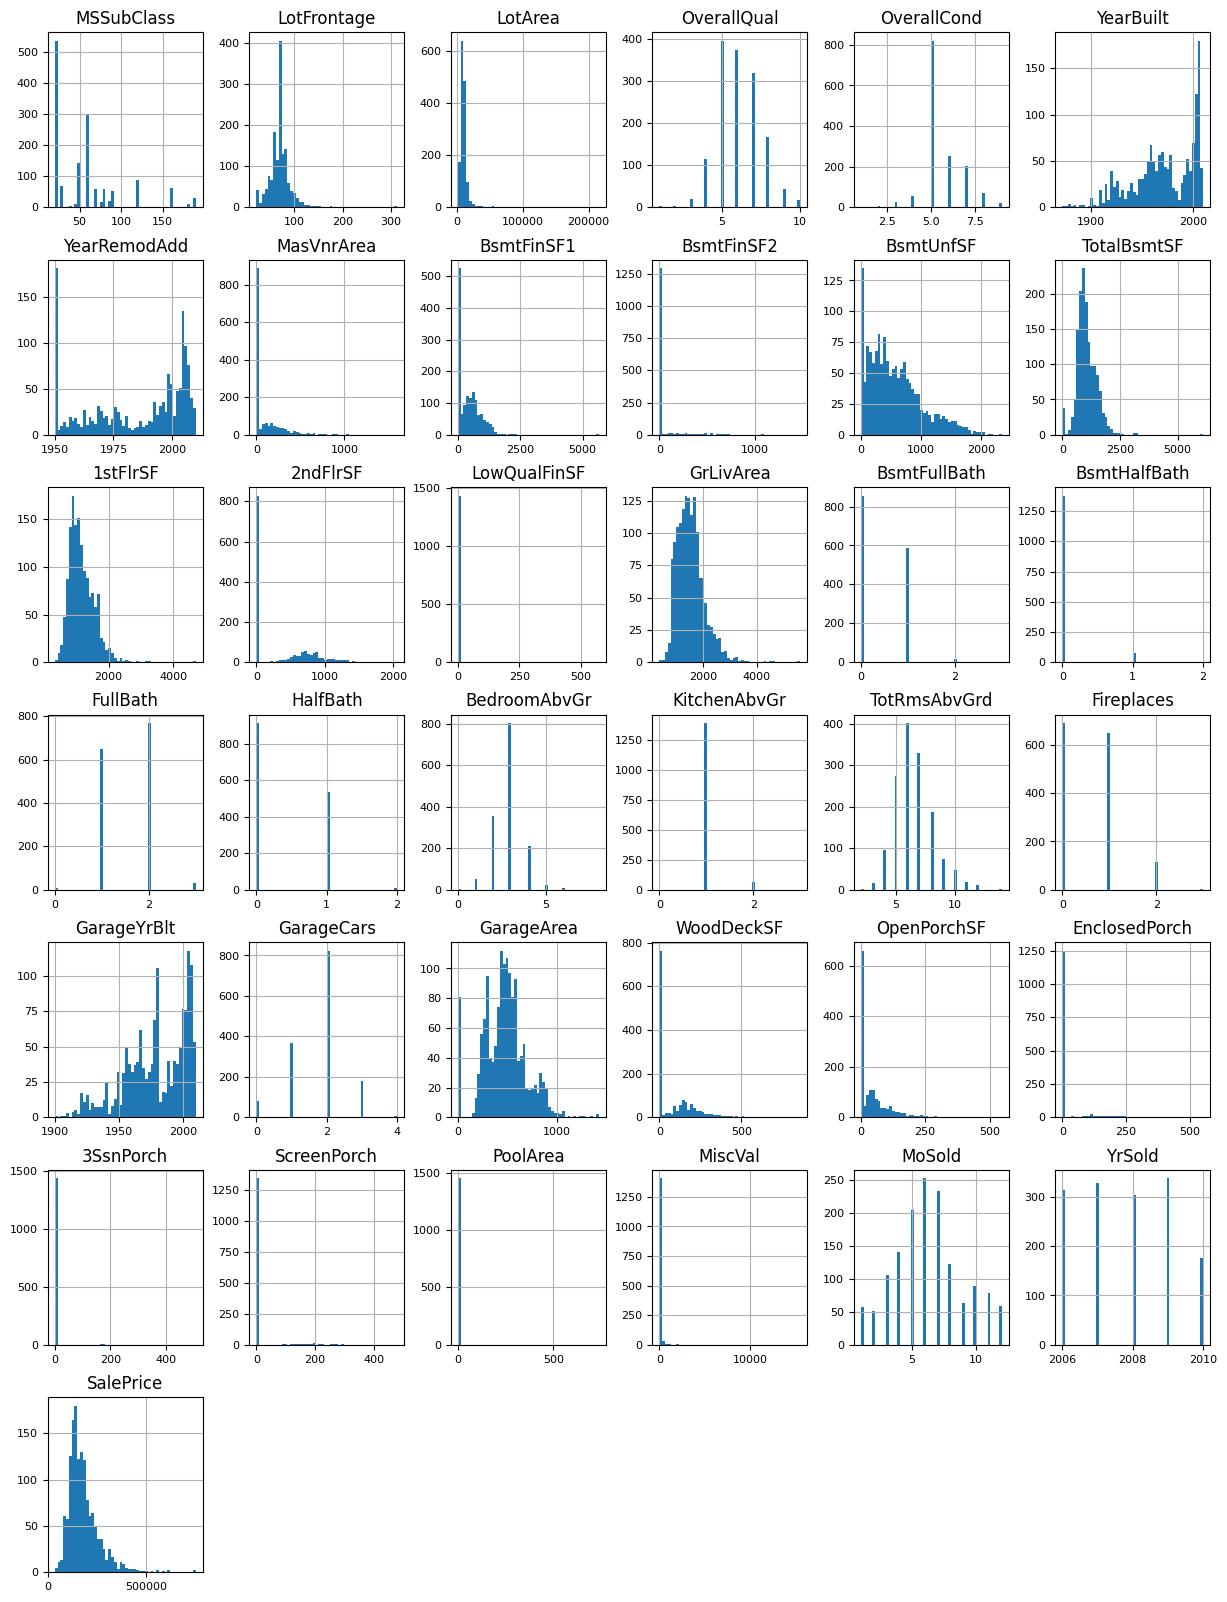

In [ ]:
train_num.hist(figsize=(15, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [ ]:
skewness = train_num.apply(lambda x: skew(x))
skewness.sort_values(ascending=False)


MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.674865
LotFrontage       2.406671
OpenPorchSF       2.361912
SalePrice         1.880941
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
2ndFlrSF          0.812194
OverallCond       0.692355
TotRmsAbvGrd      0.675646
HalfBath          0.675203
Fireplaces        0.648898
BsmtFullBath      0.595454
OverallQual       0.216721
MoSold            0.211835
BedroomAbvGr      0.211572
GarageArea        0.179796
YrSold            0.096170
FullBath          0.036524
GarageCars       -0.342197
YearRemodAdd     -0.503044
YearBuilt        -0.612831
GarageYrBlt      -0.677636
d

In [ ]:
#train_num = np.log1p(train_num)

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

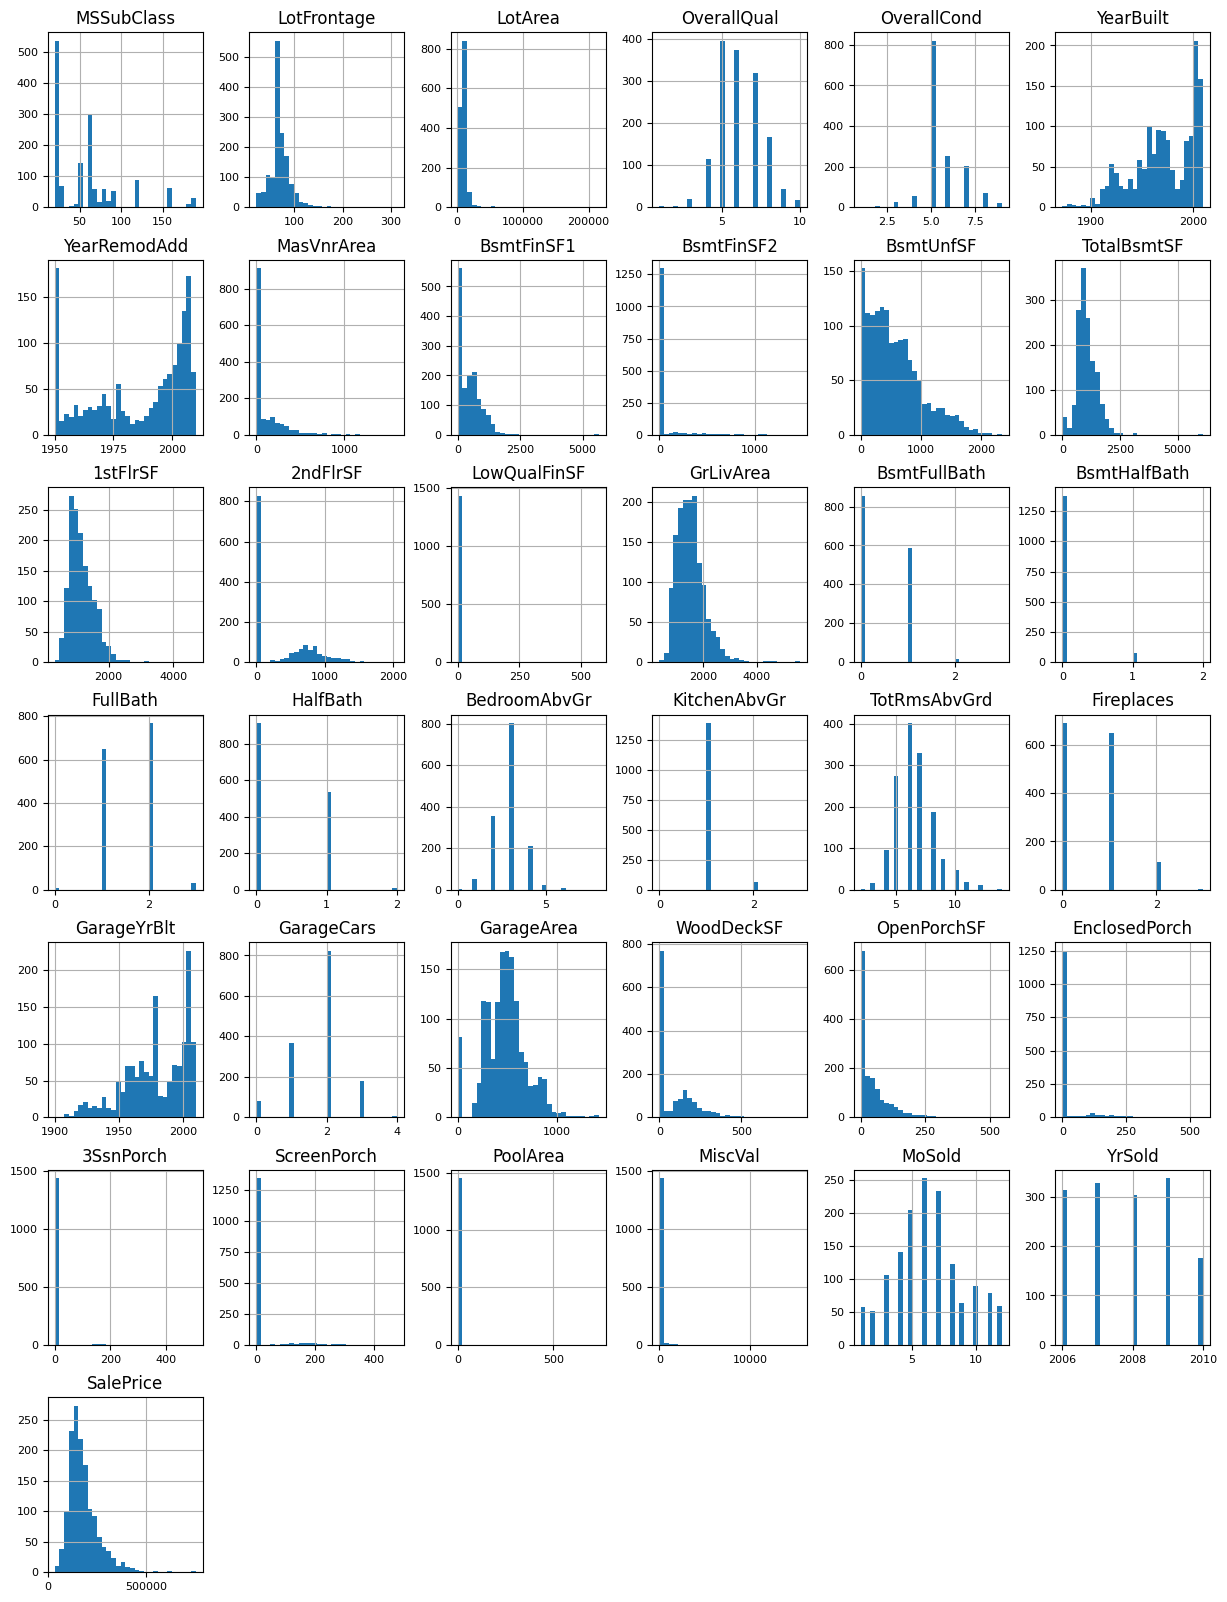

In [ ]:

train_num.hist(figsize=(15, 20), bins=30, xlabelsize=8, ylabelsize=8)

In [ ]:
skewness = train_num.apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.674865
LotFrontage       2.406671
OpenPorchSF       2.361912
SalePrice         1.880941
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
2ndFlrSF          0.812194
OverallCond       0.692355
TotRmsAbvGrd      0.675646
HalfBath          0.675203
Fireplaces        0.648898
BsmtFullBath      0.595454
OverallQual       0.216721
MoSold            0.211835
BedroomAbvGr      0.211572
GarageArea        0.179796
YrSold            0.096170
FullBath          0.036524
GarageCars       -0.342197
YearRemodAdd     -0.503044
YearBuilt        -0.612831
GarageYrBlt      -0.677636
d

### 1.3.2 Test data

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

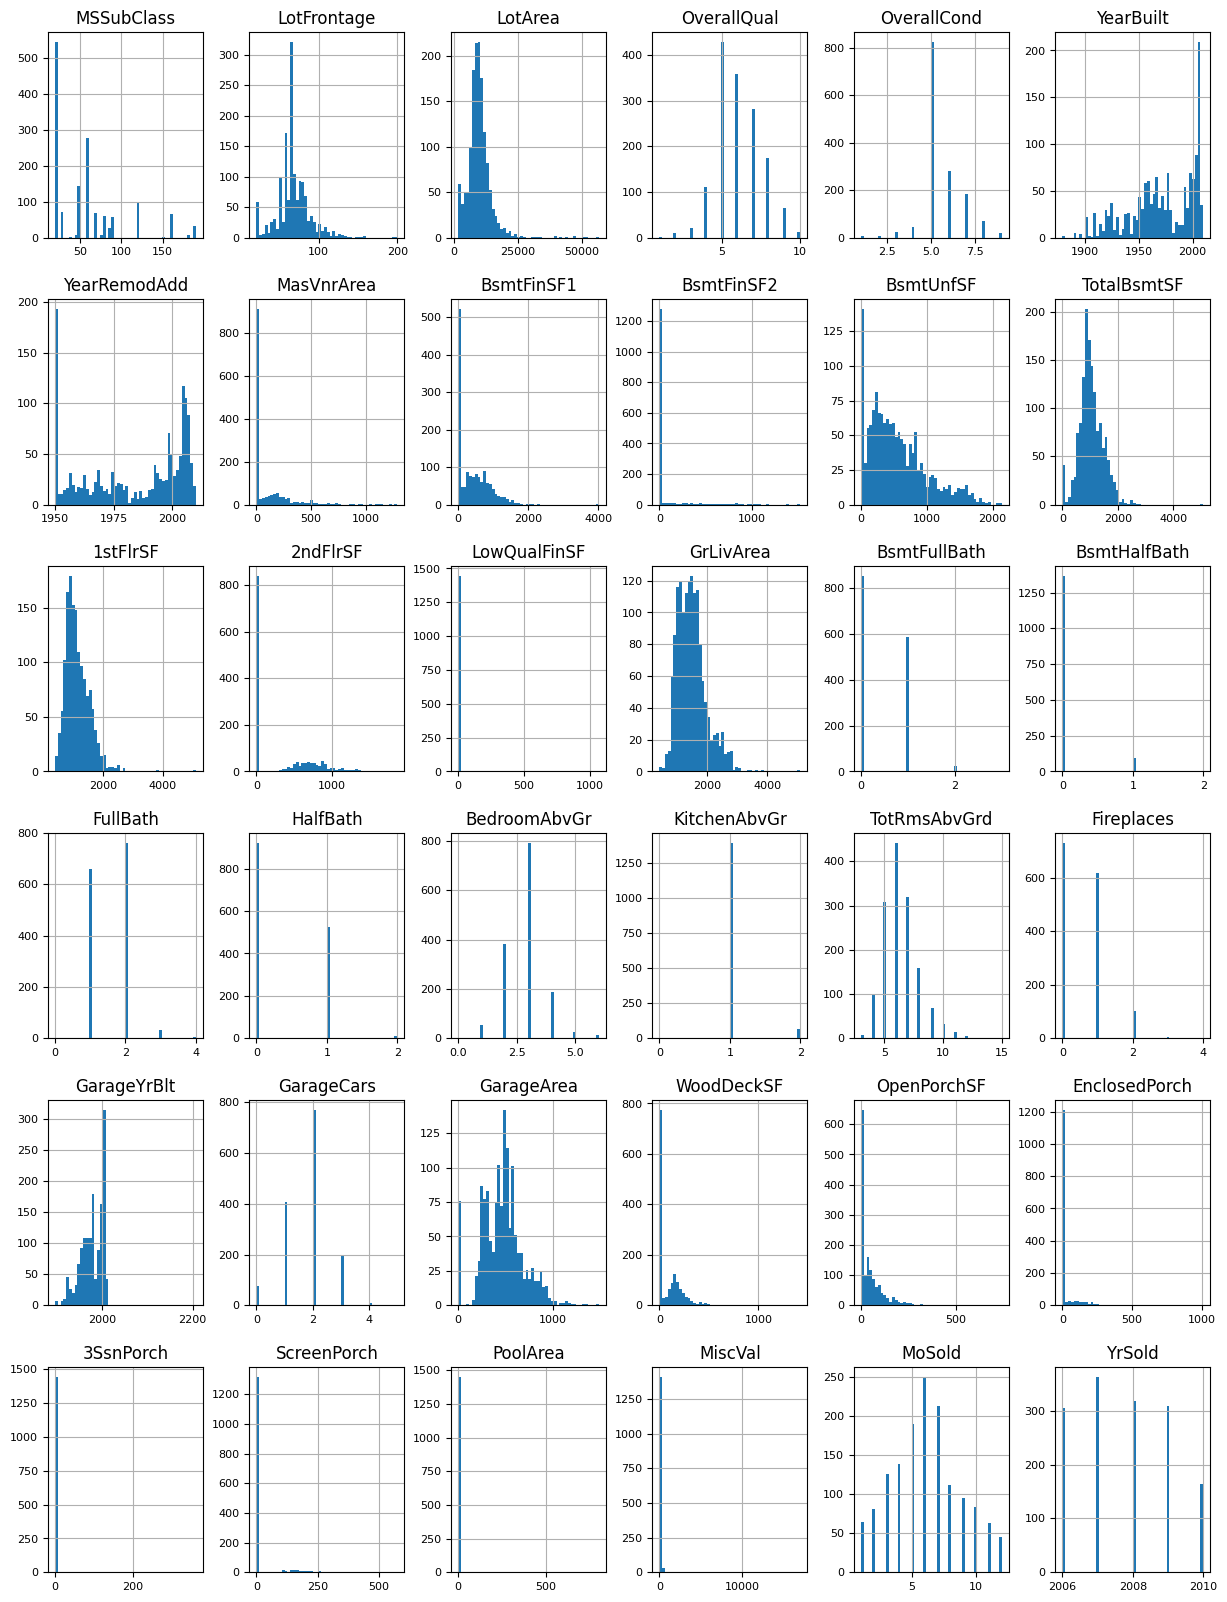

In [ ]:
test_num.hist(figsize=(15, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [ ]:
skewness = test_num.apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

PoolArea         20.176117
MiscVal          20.054543
LowQualFinSF     16.150628
3SsnPorch        12.511336
EnclosedPorch     4.664371
KitchenAbvGr      4.074860
BsmtFinSF2        4.038796
ScreenPorch       3.784349
BsmtHalfBath      3.779085
LotArea           3.112013
OpenPorchSF       2.685015
MasVnrArea        2.546947
WoodDeckSF        2.128569
1stFlrSF          1.556592
MSSubClass        1.345305
BsmtFinSF1        1.165227
GrLivArea         1.129240
BsmtUnfSF         0.919678
2ndFlrSF          0.911944
TotRmsAbvGrd      0.841731
Fireplaces        0.819015
TotalBsmtSF       0.813285
LotFrontage       0.754415
HalfBath          0.713993
BsmtFullBath      0.651195
OverallCond       0.448703
BedroomAbvGr      0.436174
GarageArea        0.299964
FullBath          0.295534
MoSold            0.182834
OverallQual       0.181010
YrSold            0.168813
GarageCars       -0.107659
GarageYrBlt      -0.170538
YearRemodAdd     -0.399495
YearBuilt        -0.587052
dtype: float64

In [ ]:
#test_num = np.log1p(test_num)

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

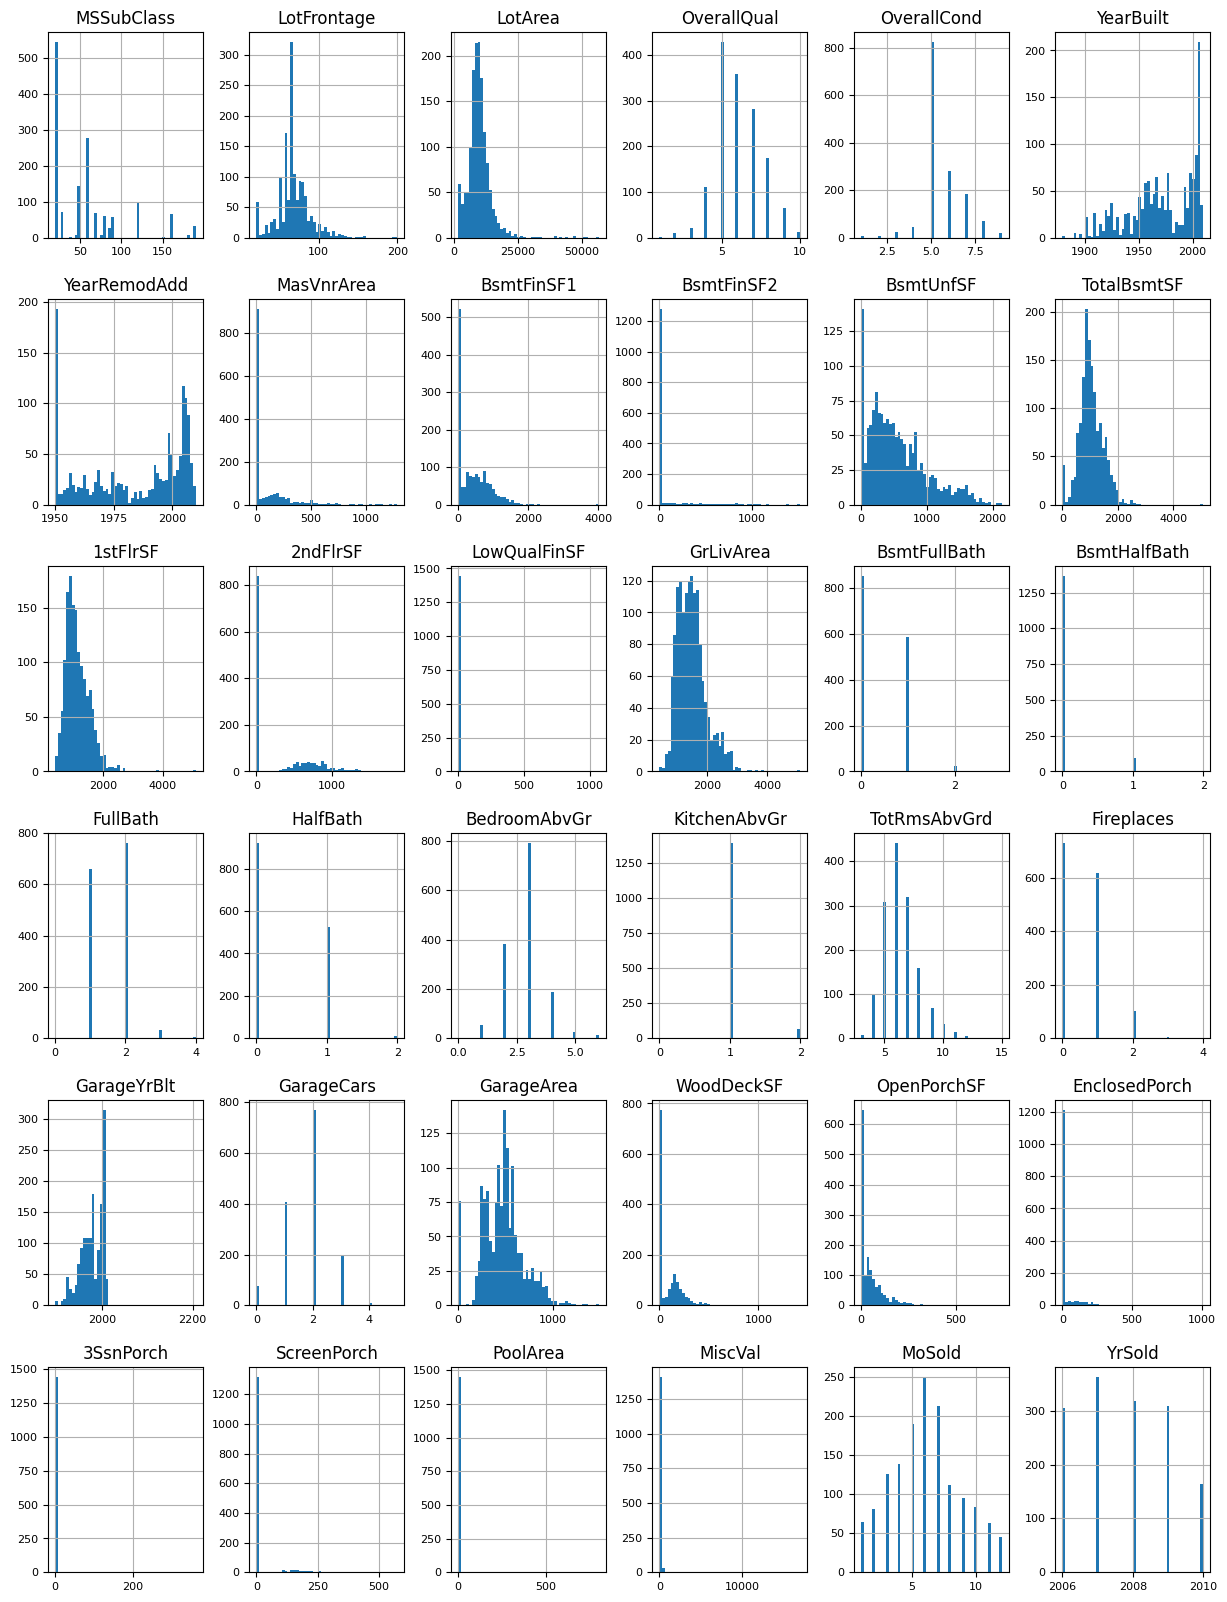

In [ ]:
test_num.hist(figsize=(15, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [ ]:
skewness = test_num.apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

PoolArea         20.176117
MiscVal          20.054543
LowQualFinSF     16.150628
3SsnPorch        12.511336
EnclosedPorch     4.664371
KitchenAbvGr      4.074860
BsmtFinSF2        4.038796
ScreenPorch       3.784349
BsmtHalfBath      3.779085
LotArea           3.112013
OpenPorchSF       2.685015
MasVnrArea        2.546947
WoodDeckSF        2.128569
1stFlrSF          1.556592
MSSubClass        1.345305
BsmtFinSF1        1.165227
GrLivArea         1.129240
BsmtUnfSF         0.919678
2ndFlrSF          0.911944
TotRmsAbvGrd      0.841731
Fireplaces        0.819015
TotalBsmtSF       0.813285
LotFrontage       0.754415
HalfBath          0.713993
BsmtFullBath      0.651195
OverallCond       0.448703
BedroomAbvGr      0.436174
GarageArea        0.299964
FullBath          0.295534
MoSold            0.182834
OverallQual       0.181010
YrSold            0.168813
GarageCars       -0.107659
GarageYrBlt      -0.170538
YearRemodAdd     -0.399495
YearBuilt        -0.587052
dtype: float64

## 1.3 Categorial data

In [ ]:
train_categorial = train_data.select_dtypes(include = 'object')
test_categorial = test_data.select_dtypes(include = 'object')


In [ ]:
train_categorial.shape, test_categorial.shape

((1460, 43), (1459, 43))

In [ ]:
test_train_cat = pd.concat([train_categorial, test_categorial], axis = 0)

In [ ]:
test_train_cat = pd.get_dummies(test_train_cat)
test_train_cat.sample(5)

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1372,False,False,False,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
133,False,False,False,True,False,False,True,True,False,True,...,False,False,False,True,False,False,False,False,True,False
228,False,False,False,True,False,False,True,True,False,True,...,False,False,False,True,False,False,False,False,True,False
710,False,False,False,True,False,False,True,True,False,True,...,False,False,False,True,False,False,False,False,True,False
2,False,False,False,True,False,False,True,True,False,True,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
test_train_cat.shape

(2919, 251)

In [ ]:
train_categorial = test_train_cat.iloc[:1460]
test_categorial = test_train_cat.iloc[1460:]

In [ ]:
train_categorial.shape, test_categorial.shape

((1460, 251), (1459, 251))

## 1.5 Feature correlation

In [ ]:
list(set(train_data.dtypes.tolist()))

[dtype('O'), dtype('int64'), dtype('float64')]

In [ ]:
train_n = train_data.select_dtypes(include = ['int64','float64'])
corr = train_n.corr()
corr.sort_values(["SalePrice"], ascending = False, inplace = True)
print(corr.SalePrice)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

<Axes: >

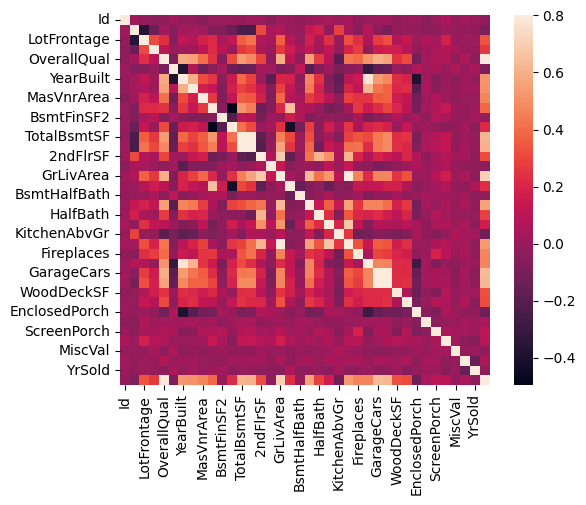

In [ ]:
corr_mat = train_n.corr()
sns.heatmap(corr_mat, vmax=.8, square=True)

# 2. Modeling

In [ ]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

## 2.1 Split data into train and validation

In [ ]:
train = pd.concat([train_categorial,train_num],axis=1)
test = pd.concat([test_categorial, test_num], axis=1)
train.shape, test.shape

((1460, 288), (1459, 287))

In [ ]:

X = train.drop('SalePrice', axis = 1)
y = train.SalePrice

X_test_data = test

In [ ]:
X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size = 0.4, random_state=0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((876, 287), (584, 287), (876,), (584,))

## 2.3 Create model
- simple Linear Regression
- Ridge
- Lasso

### 2.3.1 Linear Regression

In [ ]:
LinearReg = LinearRegression()
LinearReg.fit(X_train, y_train)
y_hat_train = LinearReg.predict(X_train)
y_hat_test = LinearReg.predict(X_test)

print("Linear Regression simple split score: ")
print("train RMSE:", np.sqrt(mean_squared_error(y_hat_train, y_train)))
print("train R2:", r2_score(y_hat_train, y_train))
print("test RMSE:", np.sqrt(mean_squared_error(y_hat_test, y_test)))
print("test R2:", r2_score(y_hat_test, y_test))

Linear Regression simple split score: 
train RMSE: 17417.12273244932
train R2: 0.9498556049391039
test RMSE: 355707717.6077105
test R2: -0.0013722656875099215


In [ ]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
result_RMSE_train = []
result_R2_train = []
result_RMSE_test = []
result_R2_test = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_hat_train_cv = model.predict(X_train)
    y_hat_test_cv = model.predict(X_test)
    result_RMSE_train.append(np.square(mean_squared_error(y_hat_train_cv, y_train)))
    result_R2_train.append(r2_score(y_hat_train_cv, y_train))
    result_RMSE_test.append(np.square(mean_squared_error(y_hat_test_cv, y_test)))
    result_R2_test.append(r2_score(y_hat_test_cv, y_test))

print("Linear Regression CV score: ")
print(f"train RMSE: {sum(result_RMSE_train) / len(result_RMSE_train):.5f}")
print(f"train R2: {sum(result_R2_train) / len(result_R2_train):.5f}")
print(f"test RMSE: {sum(result_RMSE_test) / len(result_RMSE_test):.5f}")
print(f"test R2: {sum(result_R2_test) / len(result_R2_test):.5f}")


Linear Regression CV score: 
train RMSE: 154241426090095808.00000
train R2: 0.93367
test RMSE: 7349018880333030774690522744981857641693184.00000
test R2: 0.15631


### 2.3.2 Ridge

In [ ]:
paramGrid = {"alphas": [0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1, 3, 6, 10, 30, 60]}

model_Ridge = RidgeCV()

grid = GridSearchCV(model_Ridge, paramGrid, scoring='neg_root_mean_squared_error', cv=5)
res_grid = grid.fit(X_train, y_train)


In [ ]:
res_grid.best_params_

{'alphas': 30}

In [ ]:
Ridge = RidgeCV(alphas =60)
Ridge.fit(X_train, y_train)
y_hat_train = Ridge.predict(X_train)
y_hat_test = Ridge.predict(X_test)
print("Ridge score: ")
print("train RMSE:", mean_squared_error(y_hat_train, y_train, squared = False))
print("train R2:", r2_score(y_hat_train, y_train))
print("test RMSE:", mean_squared_error(y_hat_test, y_test)))
print("test R2:", r2_score(y_hat_test, y_test))

Ridge score: 
train RMSE: 29408.8327256832
train R2: 0.840877505291468
test RMSE: 20798.01956440742
test R2: 0.9060216626360449


In [ ]:
kf = KFold(n_splits=9, random_state=42, shuffle=True)
result_RMSE_train = []
result_R2_train = []
result_RMSE_test = []
result_R2_test = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_ridge = RidgeCV(alphas = 60)
    model_ridge.fit(X_train, y_train)

    y_hat_train_cv = model.predict(X_train)
    y_hat_test_cv = model.predict(X_test)
    result_RMSE_train.append(mean_squared_error(y_hat_train_cv, y_train, squared = False))
    result_R2_train.append(r2_score(y_hat_train_cv, y_train))
    result_RMSE_test.append(np.square(mean_squared_error(y_hat_test_cv, y_test)))
    result_R2_test.append(r2_score(y_hat_test_cv, y_test))

print("Ridge CV score: ")
print(f"train RMSE: {sum(result_RMSE_train) / len(result_RMSE_train):.5f}")
print(f"train R2: {sum(result_R2_train) / len(result_R2_train):.5f}")
print(f"test RMSE: {sum(result_RMSE_test) / len(result_RMSE_test):.5f}")
print(f"test R2: {sum(result_R2_test) / len(result_R2_test):.5f}")

Ridge CV score: 
train RMSE: 22865.20059
train R2: 0.90664
test RMSE: 306110471189443136.00000
test R2: 0.90456


### 2.3.3 Lasso

In [ ]:
param_grid = {
    'alpha': [0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1, 3, 6, 10, 30, 60]
}


grid = GridSearchCV(estimator=Lasso(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error')

res_grid = grid.fit(X_train, y_train)

In [ ]:
res_grid.best_params_

{'alpha': 60}

In [ ]:
model = Lasso(alpha = 60)
model.fit(X_train, y_train)
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)
print("Lasso score: ")
print("train RMSE:", np.sqrt(mean_squared_error(y_hat_train, y_train)))
print("train R2:", r2_score(y_hat_train, y_train))
print("test RMSE:", np.sqrt(mean_squared_error(y_hat_test, y_test)))
print("test R2:", r2_score(y_hat_test, y_test))

Lasso score: 
train RMSE: 20543.29312735671
train R2: 0.9228061709192288
test RMSE: 30450.301233999497
test R2: 0.8489009636493816


In [ ]:
kf = KFold(n_splits=5, random_state=21, shuffle=True)
result_RMSE_train = []
result_R2_train = []
result_RMSE_test = []
result_R2_test = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = Lasso(alpha = 60)
    model.fit(X_train, y_train)

    y_hat_train_cv = model.predict(X_train)
    y_hat_test_cv = model.predict(X_test)
    result_RMSE_train.append(np.square(mean_squared_error( y_train, y_hat_train_cv)))
    result_R2_train.append(r2_score(y_hat_train_cv, y_train))
    result_RMSE_test.append(np.square(mean_squared_error(y_hat_test_cv, y_test)))
    result_R2_test.append(r2_score(y_hat_test_cv, y_test))

print("Lasso CV score: ")
print(f"train RMSE: {sum(result_RMSE_train) / len(result_RMSE_train):.5f}")
print(f"train R2: {sum(result_R2_train) / len(result_R2_train):.5f}")
print(f"test RMSE: {sum(result_RMSE_test) / len(result_RMSE_test):.5f}")
print(f"test R2: {sum(result_R2_test) / len(result_R2_test):.5f}")

Lasso CV score: 
train RMSE: 204351634521861216.00000
train R2: 0.92096
test RMSE: 1427456946082224384.00000
test R2: 0.82837


# Submussion

In [ ]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
result_RMSE_train = []
result_R2_train = []
result_RMSE_test = []
result_R2_test = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_ridge = RidgeCV(alphas = 30)
    model_ridge.fit(X_train, y_train)

    y_hat_test = model_ridge.predict(X_test_data)


In [ ]:
submission = pd.DataFrame(columns =['Id','SalePrice'])
submission['Id'] = test_Id
submission['SalePrice'] = y_hat_test
submission.to_csv("submission.csv", index=False)